In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, MaxPool2D, Flatten
import kerastuner as kt
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hypermodel import HyperModel
from kerastuner.engine.hyperparameters import HyperParameters
from tensorflow.keras.callbacks import TensorBoard
import time
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


2026-01-07 02:50:16.135488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767754216.148302      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767754216.152245      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 02:50:16.168593: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/kaggle/input/train.csv.zip
/kaggle/input/sample_submission.csv.zip
/kaggle/input/test.zip
/kaggle/input/test_tfrecords.zip
/kaggle/input/train_tfrecords.zip
/kaggle/input/test_images.zip
/kaggle/input/train.csv
/kaggle/input/train.zip
/kaggle/input/description.md
/kaggle/input/train_images.zip
/kaggle/input/sample_submission.csv
/kaggle/input/label_num_to_disease_map.json
/kaggle/input/test_images/2574872277.jpg
/kaggle/input/test_images/1449210447.jpg
/kaggle/input/test_images/1269550303.jpg
/kaggle/input/test_images/1411799307.jpg
/kaggle/input/test_images/2474336811.jpg
/kaggle/input/test_images/2513489893.jpg
/kaggle/input/test_images/138763396.jpg
/kaggle/input/test_images/1454379342.jpg
/kaggle/input/test_images/135606795.jpg
/kaggle/input/test_images/244091101.jpg
/kaggle/input/test_images/1305931861.jpg
/kaggle/input/test_images/2431640165.jpg
/kaggle/input/test_images/262767997.jpg
/kaggle/input/test_images/2562280265.jpg
/kaggle/input/test_images/1249688756.jpg
/kaggle/input

/tmp/ipykernel_11/3350804331.py:11: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


(600, 800, 3)


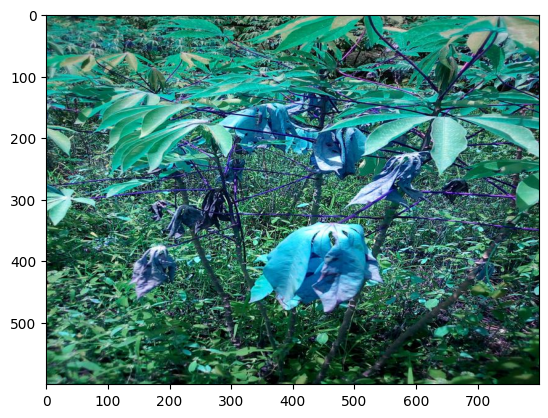

In [2]:
import matplotlib.pyplot as plt
for f in os.listdir('../input/cassava-leaf-disease-classification/train_images')[1000:1001]:
    img=cv2.imread(os.path.join('../input/cassava-leaf-disease-classification/train_images',f))
    plt.imshow(img)
    print(img.shape)
    plt.show        
    
epochs=10


In [3]:
def create_df(training_images=100,image_directory='../input/cassava-leaf-disease-classification/train_images',test_dir='../input/cassava-leaf-disease-classification/test_images'):
    

    '''
    Returns dataframe given the training images and image directory  
     
    '''

    train=pd.read_csv('../input/cassava-leaf-disease-classification/train.csv') 
    label=list(train.iloc[:,1])
    label=[[x] for x in label]

    im_di=[]
    
    test_di=[]

    ###CREATING DATAFRAME FOR FLOW FROM DATAFRAME 
    for f in os.listdir(image_directory)[:training_images]:
        im_di.append(os.path.join(image_directory,f))
        

    train_lis=list(zip(im_di,label))
    train_df=pd.DataFrame(train_lis)
    train_df=train_df.rename(columns={0:'x_col',1:'y_col'})
    
    ####FOR TEST DATAFRAME 
    for fi in os.listdir(test_dir):
        test_di.append(os.path.join(test_dir,fi))
        
        
    test_df=pd.DataFrame(test_di,columns=['x'])
    test_df['y']=None 
    
    
    return train_df,test_df


def hyper_model():  
    
    '''
    Hypermodel for keras tuner 
    
    '''


    model = tf.keras.applications.ResNet50V2(include_top=False,classes=5,input_shape=(128,128,3))

    for layers in model.layers[:]:                      ####NON_TRAIN_LAY
        layers.trainable=False

    flat=tf.keras.layers.Flatten()(model.output)
    
    #drop=tf.keras.layers.Dropout(config['dpout1'])(flat)                       ####DROPOUT1
    
    #out1=Dense(config['dense_layer'],activation='relu')(drop)                  ####CONFIG DENSE LAYER NODES
    
    out2=Dense(5,activation='softmax')(flat)

    f_mod=tf.keras.Model(inputs=model.input,outputs=out2)     
    
    f_mod.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
    
    return f_mod



def model1():
    
    model=Sequential()
    
    model.add(Conv2D(64,kernel_size=3,activation='relu',input_shape=(128,128,3),padding='same'))
        
    model.add(Conv2D(128,kernel_size=3,activation='relu',padding='same'))
    
    model.add(MaxPool2D(pool_size=(2,2),strides=(2,2)))
    
    model.add(Conv2D(256,kernel_size=3,activation='relu',padding='same'))
    
    model.add(MaxPool2D(pool_size=(2,2),strides=(2,2)))
    
    model.add(Conv2D(512,kernel_size=3,activation='relu',padding='same'))
    
    model.add(MaxPool2D(pool_size=(2,2),strides=(3,3)))
            
    model.add(Conv2D(1024,kernel_size=3,activation='relu',padding='same'))
    
    model.add(MaxPool2D(pool_size=(2,2),strides=(3,3)))

    model.add(Flatten())
    
    model.add(Dense(units=512,activation='relu'))
    
    model.add(Dense(units=128,activation='relu'))

    model.add(Dense(units=5,activation='softmax'))
    
    model.compile(optimizer="Adam", loss="categorical_crossentropy", metrics=["accuracy"])

    return model 


def test_pre_process(dataframe,test_df,image_size=128,batch_size=64,valid_split=0.15):

    '''
    
    Data preprocessing based on image size, batch size and validation split using image data generator
    
    return train and validation image data generators 
    
    '''
    
    im_dg=tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255,validation_split=valid_split)
    
    te_dg=tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    
    
    train=im_dg.flow_from_dataframe(dataframe,x_col="x_col",y_col="y_col",class_mode='categorical',batch_size=batch_size,target_size=(image_size,image_size),subset='training')
    
    valid=im_dg.flow_from_dataframe(dataframe,x_col="x_col",y_col="y_col",class_mode='categorical',batch_size=batch_size,target_size=(image_size,image_size),subset='validation')
    
    test =te_dg.flow_from_dataframe(test_df,x_col='x',y_col=None,batch_size=batch_size,target_size=(image_size,image_size),class_mode=None)

    return train,valid,test


In [4]:
model=model1()
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-07 02:50:23.558418: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767754223.559346      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 1024)   │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,726,021 (56.18 MB)

 Trainable params: 14,726,021 (56.18 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
train_df,test_df= create_df(training_images=90)

len(train_df)
test_df


,x,y
0,../input/cassava-leaf-disease-classification/t...,None
1,../input/cassava-leaf-disease-classification/t...,None
2,../input/cassava-leaf-disease-classification/t...,None
3,../input/cassava-leaf-disease-classification/t...,None
4,../input/cassava-leaf-disease-classification/t...,None
...,...,...
2672,../input/cassava-leaf-disease-classification/t...,None
2673,../input/cassava-leaf-disease-classification/t...,None
2674,../input/cassava-leaf-disease-classification/t...,None
2675,../input/cassava-leaf-disease-classification/t...,None


In [6]:
train,valid,test = test_pre_process(train_df,test_df=test_df)


Found 77 validated image filenames belonging to 5 classes.
Found 13 validated image filenames belonging to 5 classes.
Found 2676 validated image filenames.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="x". These filename(s) will be ignored.
  warnings.warn(


In [7]:
#def keras_tuning(max_trials,executions_per_trial):
    
    #tuner=kt.tuners.RandomSearch(hyper_model,max_trials=max_trials,executions_per_trial=executions_per_trial,objective='val_loss')
    
    #tuner.search_space_summary()
    
    #ear_sto=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3)

    #history=tuner.search(x=train,epochs=epochs,verbose=2,callbacks=[ear_sto],validation_data=valid)  
    
    #tuner.results_summary()
    
    #return tuner.get_best_models(num_models=1)[0]
    


In [8]:
ear_sto=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=3)
model=model
history=model.fit(x=train,epochs=epochs,verbose=2,callbacks=[ear_sto],validation_data=valid,shuffle=True)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1767754226.223044      66 service.cc:148] XLA service 0x7f1820006f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767754226.223073      66 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-07 02:50:26.251976: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1767754226.416806      66 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767754230.564043      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-01-07 02:50:32.595908: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_804', 448 bytes spill stores, 448 bytes spill loads

2026-01-07 02:50:32.777323: I external/local_xla

2/2 - 17s - 8s/step - accuracy: 0.5455 - loss: 1.3771 - val_accuracy: 0.4615 - val_loss: 1.4088
Epoch 2/10
2/2 - 0s - 141ms/step - accuracy: 0.6104 - loss: 1.2905 - val_accuracy: 0.4615 - val_loss: 1.4666
Epoch 3/10
2/2 - 0s - 134ms/step - accuracy: 0.6104 - loss: 1.3345 - val_accuracy: 0.4615 - val_loss: 1.5242
Epoch 4/10
2/2 - 0s - 144ms/step - accuracy: 0.6104 - loss: 1.3927 - val_accuracy: 0.4615 - val_loss: 1.4898


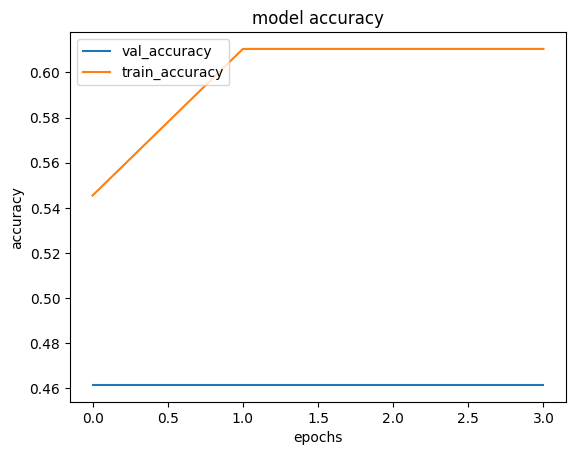

In [9]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.title('model accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')

plt.legend(['val_accuracy','train_accuracy'],loc='upper left')
plt.show()


In [10]:
#def test_to_array(dir='../input/cassava-leaf-disease-classification/test_images'):
#   test=np.array()
#   for img in dir:
#        arr=cv2.imread(os.path.join(dir,img))
#       test=cv2.resize(arr,(128,128))
#        
#        test.append(arr)
                  


#img=cv2.imread('../input/cassava-leaf-disease-classification/test_images/2216849948.jpg')
#test=cv2.resize(img,(128,128))
#plt.imshow(test)
#test=test.reshape(-1,128,128,3)
#test.shape


pred=model.predict(x=test)
label=np.argmax(pred,axis=1)

image_id=test_df.iloc[:,0]
image_ids=[]
for path in image_id:
    path=path.split('/')[-1]
    image_ids.append(path)


42/42 ━━━━━━━━━━━━━━━━━━━━ 12s 218ms/step


In [11]:
final_df=pd.DataFrame()
final_df['image_id']=image_ids
final_df['label']=label

final_df.to_csv('submission.csv',index=False)


ValueError: Length of values (2676) does not match length of index (2677)